<a href="https://colab.research.google.com/github/QSBalouch/Rain-Prediction-Model/blob/main/Rain_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import warnings
warnings.filterwarnings("ignore")

The dataset contains about 10 years of daily weather observations from different locations across Australia. Observations were drawn from numerous weather stations.

There are 23 attributes including the target variable "RainTomorrow", indicating whether or not it will rain the next day or not.

# **Loading the Dataset:**

In [4]:
import pandas as pd

In [5]:
data = pd.read_csv("weatherAUS.csv")
data

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32892,2015-10-07,Sydney,19.7,21.5,0.0,13.2,1.3,SSW,67.0,SSE,...,61.0,56.0,1029.6,1033.6,5.0,7.0,20.3,19.0,No,No
32893,2015-10-08,Sydney,17.0,21.1,0.0,6.6,2.2,ENE,35.0,ESE,...,53.0,57.0,1038.8,1036.0,7.0,7.0,18.5,19.9,No,No
32894,2015-10-09,Sydney,16.8,22.7,0.0,5.4,8.7,ENE,43.0,N,...,51.0,51.0,1034.4,1029.7,7.0,5.0,20.1,22.0,No,No
32895,2015-10-10,Sydney,15.7,24.3,0.0,6.8,9.5,E,24.0,SE,...,62.0,60.0,1028.9,1025.8,1.0,4.0,21.2,22.3,No,No


In [6]:
data.dropna(subset=["RainTomorrow"], inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        141556 non-null  float64
 3   MaxTemp        141871 non-null  float64
 4   Rainfall       140787 non-null  float64
 5   Evaporation    81350 non-null   float64
 6   Sunshine       74377 non-null   float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  132923 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   140845 non-null  float64
 12  WindSpeed3pm   139563 non-null  float64
 13  Humidity9am    140419 non-null  float64
 14  Humidity3pm    138583 non-null  float64
 15  Pressure9am    128179 non-null  float64
 16  Pressure3pm    128212 non-null  float64
 17  Cloud9am       88536 non-null   fl

# **Data Analysis:**

In [7]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 150)
sns.set_style("darkgrid")
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10,6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [ ]:
px.histogram(data, x="Location", title="Location vs Rainy Days", color='RainToday')

In [ ]:
px.histogram(
    data,
    x = "Temp3pm",
    title = "Temperature at 3 pm vs. Rain Tomorrow",
    color = 'RainTomorrow'
)

In [ ]:
px.histogram(
    data,
    x = "RainTomorrow",
    title = "Rain Tomorrow vs. Rain Today",
    color = "RainToday"
)

In [ ]:
px.scatter(
    data.sample(2000),
    title = "Min Temp vs. Max Temp",
    x = "MinTemp",
    y = "MaxTemp",
    color = "RainToday"
)

In [ ]:
px.strip(
    data.sample(2000),
    title = "Temperature (3pm) vs. Humidity (3pm)",
    x = "Temp3pm",
    y = "Humidity3pm",
    color = "RainTomorrow"
)

<Axes: title={'center': 'No of rows per year'}, xlabel='Date', ylabel='count'>

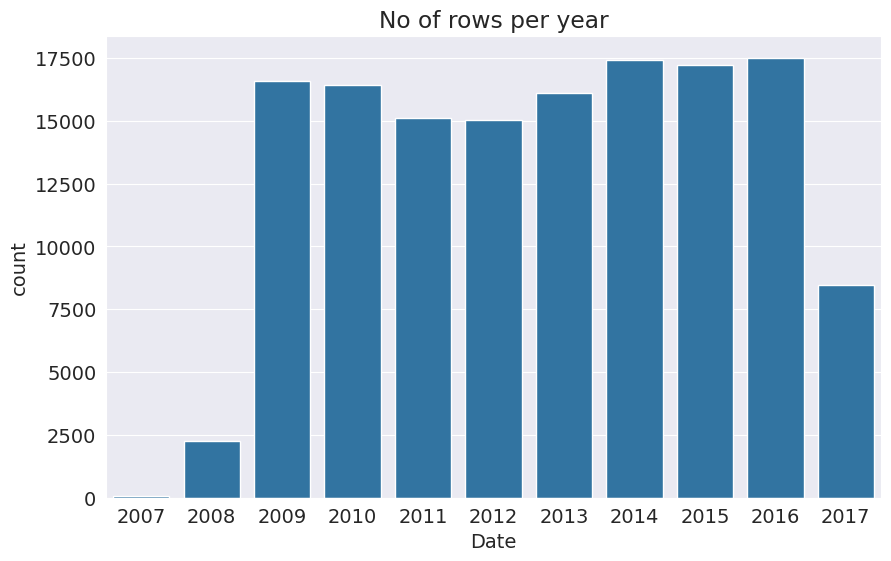

In [ ]:
plt.title('No of rows per year')
sns.countplot(x=pd.to_datetime(data.Date).dt.year)

# **Splitting Data into Train, Validation, and Test Sets**
The data was split chronologically, with records **before 2015** used for training, **2015** for validation, and records **after 2015** reserved for testing.


In [8]:
year = pd.to_datetime(data.Date).dt.year
train_data = data[year < 2015]
val_data = data[year == 2015]
test_data = data[year > 2015]

print("Train Data: ", train_data.shape)
print("Validation Data: ", val_data.shape)
print("Test Data: ", test_data.shape)

Train Data:  (23130, 23)
Validation Data:  (3798, 23)
Test Data:  (5282, 23)


# **Separating Input and Output Columns**

Lets identify the input and target columns

In [9]:
input_cols = list(data.columns)[1:-1]
target_cols = 'RainTomorrow'

train_inputs = train_data[input_cols].copy()
train_targets = train_data[target_cols].copy()

val_inputs = val_data[input_cols].copy()
val_targets = val_data[target_cols].copy()

test_inputs = test_data[input_cols].copy()
test_targets = test_data[target_cols].copy()

Let's identify the numeric and categorical columns

In [10]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

# **Data Preprocessing:**
### **1. Imputing Missing Values**

In [11]:
from sklearn.impute import SimpleImputer

In [12]:
imputer = SimpleImputer(strategy='mean').fit(train_data[numeric_cols])

In [13]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

In [14]:
train_inputs[numeric_cols].isna().sum()

,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustSpeed,0
WindSpeed9am,0
WindSpeed3pm,0
Humidity9am,0
Humidity3pm,0


### **2. Scaling Numeric Features**

In [15]:
from sklearn.preprocessing import MinMaxScaler

In [16]:
scalar = MinMaxScaler().fit(train_data[numeric_cols])

In [17]:
train_inputs[numeric_cols] = scalar.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scalar.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scalar.transform(test_inputs[numeric_cols])

In [18]:
train_inputs.describe().loc[['min', 'max']]

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### **3. Encoding Categorical Data**

In [19]:
from sklearn.preprocessing import OneHotEncoder

In [20]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore").fit(train_data[categorical_cols])

In [21]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

In [22]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

In [23]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]

# **Logistic Regression Model Training:**

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression(solver='liblinear')

In [ ]:
model.fit(X_train, train_targets)

LogisticRegression(solver='liblinear')

In [ ]:
print(model.coef_.tolist())

[[0.8926561015233506, -2.8506546812944786, 3.1903309081508344, 0.6322339141328654, -1.6032005880125477, 6.721756074981958, -0.7203273147191055, -1.4049019480674056, 0.33880688728829234, 5.977178283620254, 5.355804889636104, -8.758909344057592, -0.13922190417534674, 1.2750968856981042, 0.3692326821974678, 2.0187785742121815, 0.5899808013482936, -0.535283742524774, 0.43918884441389394, 0.009712262175461998, 0.30698015907902526, -0.38342386522922467, 0.15513575508429267, 0.41228102287071333, -0.008678878249314997, 0.01713911673459934, 0.2501163185826145, -0.013805131710559837, -0.04567109008932115, -0.47760086345756075, -0.14397462503216762, -0.5767232854888117, -0.7653887450943597, -0.2739599004184316, -0.15165986602273587, -0.5683824892301121, 0.06239613218877909, 0.02203021396171744, 0.05321547246040214, -0.9509288874068587, -0.4001326253167066, -0.013974822056423801, -0.49538724817198715, -0.4642490410336015, -0.08127768667021709, 0.35341635633455865, 0.39739496252315665, 0.5889536891

In [ ]:
print(model.intercept_)

[-2.59749959]


In [ ]:
weight_df = pd.DataFrame({
    "feature":X_train.columns,
    "weight": model.coef_.tolist()[0]
})
weight_df

,feature,weight
0,MinTemp,0.892656
1,MaxTemp,-2.850655
2,Rainfall,3.190331
3,Evaporation,0.632234
4,Sunshine,-1.603201
5,WindGustSpeed,6.721756
6,WindSpeed9am,-0.720327
7,WindSpeed3pm,-1.404902
8,Humidity9am,0.338807
9,Humidity3pm,5.977178


<Axes: xlabel='weight', ylabel='feature'>

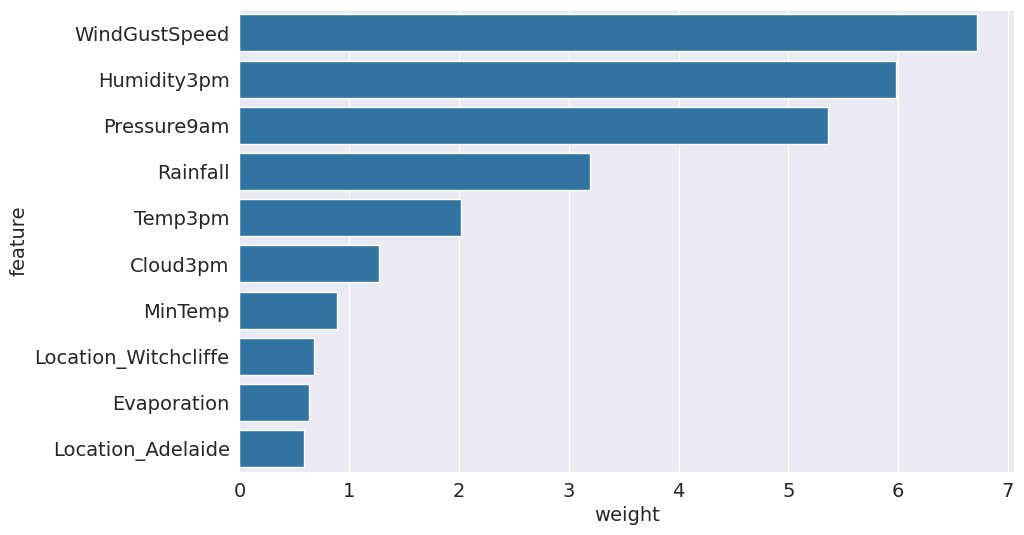

In [ ]:
sns.barplot(data=weight_df.sort_values('weight', ascending=False).head(10), x='weight', y="feature")

In [ ]:
train_preds = model.predict(X_train)
train_preds

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [ ]:
val_preds = model.predict(X_val)
val_preds

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

### **Evaluation:**

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(train_targets, train_preds)

0.8499212025700085

In [ ]:
accuracy_score(val_targets, val_preds)

0.8529975044977076

In [ ]:
accuracy_score(train_targets, train_preds)

0.8499212025700085

In [ ]:
train_probs = model.predict_proba(X_train)
train_probs

array([[0.94602599, 0.05397401],
       [0.94179614, 0.05820386],
       [0.96176003, 0.03823997],
       ...,
       [0.98839293, 0.01160707],
       [0.98437062, 0.01562938],
       [0.88460537, 0.11539463]])

In [ ]:
model.classes_

array(['No', 'Yes'], dtype=object)

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(train_targets, train_preds, normalize='true')

array([[0.94474936, 0.05525064],
       [0.47650675, 0.52349325]])

In [ ]:
def predict_and_plot(inputs,targets,name=''):
  preds = model.predict(inputs)
  accuracy = accuracy_score(targets, preds)
  print(f"Accuracy: {accuracy*100:.2f}%")

  cf = confusion_matrix(targets,preds, normalize='true')
  plt.figure()
  sns.heatmap(cf, annot=True)
  plt.xlabel('Prediction')
  plt.ylabel('Target')
  plt.title(f"{name} Confusion Matrix")
  return preds

Accuracy: 84.99%


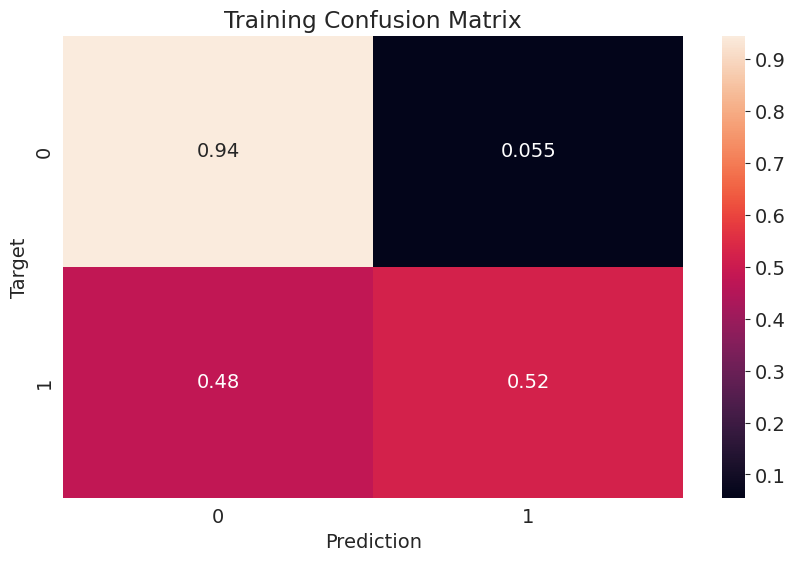

In [ ]:
train_preds = predict_and_plot(X_train, train_targets, 'Training')

Accuracy: 85.30%


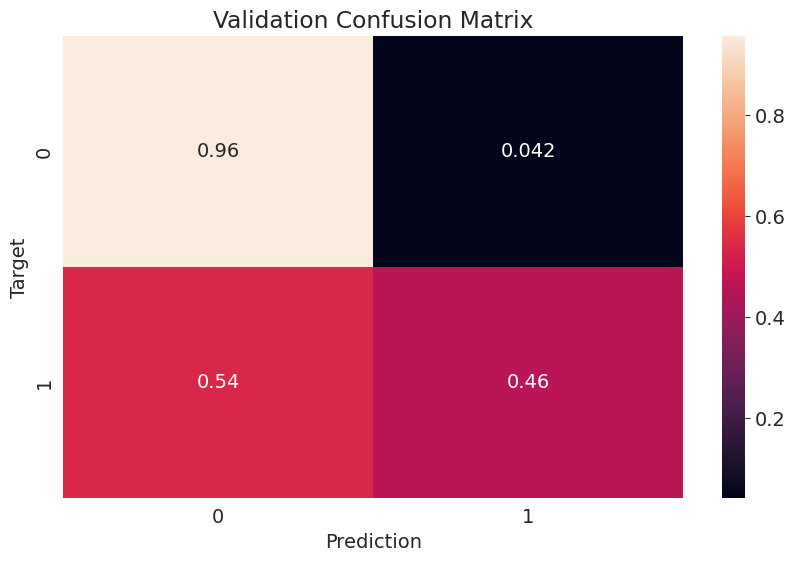

In [ ]:
val_preds = predict_and_plot(X_val, val_targets, 'Validation')

The Logistic Regression model achieves a **score of 0.8742 on the training set** and **0.8741 on the validation set**. The very similar training and validation scores indicate that the model generalizes well to unseen data with **no significant signs of overfitting**. This provides a strong baseline for comparing more complex models, such as Decision Tree, in the next step.


# **Decision Tree Model:**

### **Training**
We can use DecisionTreeClassifier from sklearn.tree to train a decision tree.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
model = DecisionTreeClassifier(random_state=42)

In [ ]:
model.fit(X_train, train_targets)

DecisionTreeClassifier(random_state=42)

An optimal decision tree has now be created using the training data

### **Evaluation**
Let's evaluate the decision tree using the accuracy score

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
train_preds = model.predict(X_train)

In [ ]:
train_preds

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [ ]:
pd.value_counts(train_preds)

,count
No,76707
Yes,22281


In [ ]:
accuracy_score(train_preds, train_targets)

0.9999797955307714

The decision tree also return probablities for each prediction

In [ ]:
train_probs = model.predict_proba(X_train)

In [ ]:
train_probs

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

Seems like decision tree is quite confident about its predictions.

The training set accuracy is close to 100%. But we can't rely solely on training set accuracy. We must evaluate the accuracy on validation set too.

We can make predictions and compute accuray in just one step by using model.score

In [ ]:
model.score(X_val, val_targets)

0.7914804712436887

Although the training accuracy is 100%, the accuracy on the validation set is just about 79%, which is only marginally better than always predicting "No"

In [ ]:
val_targets.value_counts() / len(val_targets)

,count
RainTomorrow,
No,0.788289
Yes,0.211711


It appears that the model has learned the training examples perfect, and doesn't generalize well to previously unseen examples. The phenomenon is called "overfitting", and reducing overfitting is one of the most important parts of machine learning projects.

### **Visualization**
We can visualize the decision tree learned from the training data.

In [ ]:
from sklearn.tree import plot_tree, export_text

[Text(0.5, 0.875, 'Humidity3pm <= 0.715\ngini = 0.349\nsamples = 98988\nvalue = [76705, 22283]'),
 Text(0.25, 0.625, 'Rainfall <= 0.004\ngini = 0.248\nsamples = 82418\nvalue = [70439.0, 11979.0]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Sunshine <= 0.532\ngini = 0.198\nsamples = 69252\nvalue = [61538.0, 7714.0]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'Humidity3pm <= 0.513\ngini = 0.438\nsamples = 13166\nvalue = [8901, 4265]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'Humidity3pm <= 0.825\ngini = 0.47\nsamples = 16570\nvalue = [6266, 10304]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'WindGustSpeed <= 0.279\ngini = 0.499\nsamples = 9136\nvalue = [4804, 4332]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Rainfall <= 0.01\ngini = 0.316\nsamples = 7434\nvalue = [1462, 5972]'),
 Text(0.8125, 0.125,

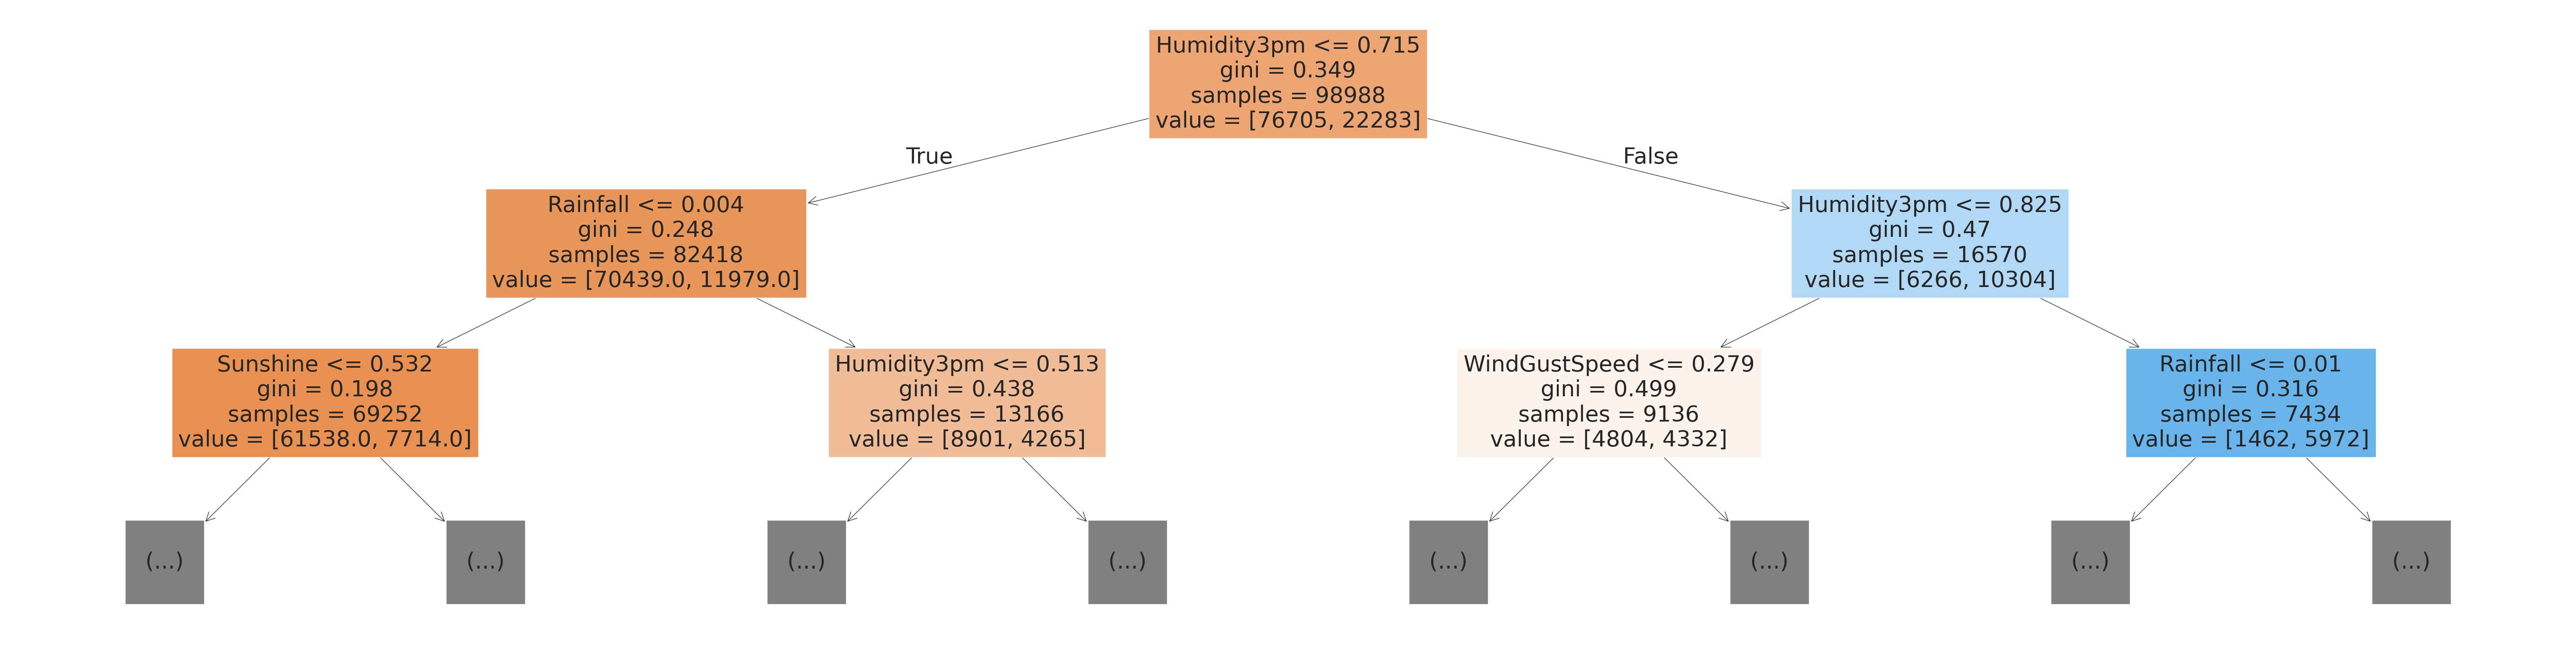

In [ ]:
plt.figure(figsize=(80,20))
plot_tree(model, feature_names=X_train.columns, max_depth=2, filled=True)

Can you see how a model classifies a given input as a series of decisions? The tree is truncated here, but following any path from the root node down to a leaf will result in "Yes" or "No". Do you see how a decision tree differs from a logistic regression model?
### **How a decision tree is created**
Note that gini value in each box. This is the loss function used by decision tree to decide which column should be used for splitting the data, and what point the column should be split. A lower gini index indicates a better split. A perfect split (only one class on each side) has a gini index of 0.

Let's check the depth of the tree that was created

In [ ]:
model.tree_.max_depth

48

We can also display tree as text, as below:

In [ ]:
tree_text = export_text(model, max_depth=10, feature_names=list(X_train.columns))

In [ ]:
print(tree_text[:5000])

|--- Humidity3pm <= 0.72
|   |--- Rainfall <= 0.00
|   |   |--- Sunshine <= 0.53
|   |   |   |--- Pressure3pm <= 0.57
|   |   |   |   |--- WindGustSpeed <= 0.36
|   |   |   |   |   |--- Humidity3pm <= 0.28
|   |   |   |   |   |   |--- WindDir9am_NE <= 0.50
|   |   |   |   |   |   |   |--- Location_Watsonia <= 0.50
|   |   |   |   |   |   |   |   |--- Cloud9am <= 0.83
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm <= 0.07
|   |   |   |   |   |   |   |   |   |   |--- Pressure3pm <= 0.44
|   |   |   |   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |   |   |   |--- Pressure3pm >  0.44
|   |   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |   |--- WindSpeed3pm >  0.07
|   |   |   |   |   |   |   |   |   |   |--- MinTemp <= 0.32
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |   |   |   |   |   |--- MinTemp >  0.32
|   |   |   |   |   |   |   |   |   |   |   |--- truncated

### **Feature Importance**
Based on the gini index computations, a decision tree assigns an "importance" value to each feature. These values can be used to interpret the results given by a decision tree.

In [ ]:
model.feature_importances_

array([3.62010628e-02, 3.15410676e-02, 5.82546581e-02, 2.48322505e-02,
       5.08451879e-02, 5.48721143e-02, 2.68802557e-02, 3.04280561e-02,
       4.03337790e-02, 2.61055351e-01, 3.48742762e-02, 6.12186954e-02,
       1.31134817e-02, 1.92748524e-02, 3.34112355e-02, 2.99278458e-02,
       2.30948611e-03, 2.00269251e-03, 1.22618570e-03, 8.11664184e-04,
       1.56183476e-03, 1.09521007e-03, 6.53443035e-04, 1.63792732e-03,
       1.20114791e-03, 1.29168232e-03, 7.95286728e-04, 2.19922929e-03,
       1.74184984e-03, 2.68124067e-04, 1.18093830e-03, 1.59786025e-03,
       5.30953230e-04, 9.03108598e-04, 1.50171649e-03, 1.07133054e-03,
       8.07088742e-04, 8.03223575e-04, 1.79364244e-03, 2.09913294e-03,
       3.41903091e-04, 6.05150911e-04, 1.38447165e-03, 1.77902307e-03,
       1.35089758e-03, 8.51982460e-04, 6.83232777e-04, 1.56566910e-03,
       9.99683866e-04, 2.15218515e-03, 8.86321975e-04, 1.53907978e-03,
       8.71630249e-04, 1.28577975e-03, 1.60066700e-03, 5.28075720e-04,
      

In [ ]:
X_train.columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm',
       ...
       'WindDir3pm_SSE', 'WindDir3pm_SSW', 'WindDir3pm_SW', 'WindDir3pm_W',
       'WindDir3pm_WNW', 'WindDir3pm_WSW', 'WindDir3pm_nan', 'RainToday_No',
       'RainToday_Yes', 'RainToday_nan'],
      dtype='object', length=119)

Let's turn this into a dataframe and visualize the most important features.

In [ ]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values('importance', ascending=False)

In [ ]:
importance_df

,feature,importance
9,Humidity3pm,0.261055
11,Pressure3pm,0.061219
2,Rainfall,0.058255
5,WindGustSpeed,0.054872
4,Sunshine,0.050845
8,Humidity9am,0.040334
0,MinTemp,0.036201
10,Pressure9am,0.034874
14,Temp9am,0.033411
1,MaxTemp,0.031541


<Axes: title={'center': 'Feature Importance'}, xlabel='importance', ylabel='feature'>

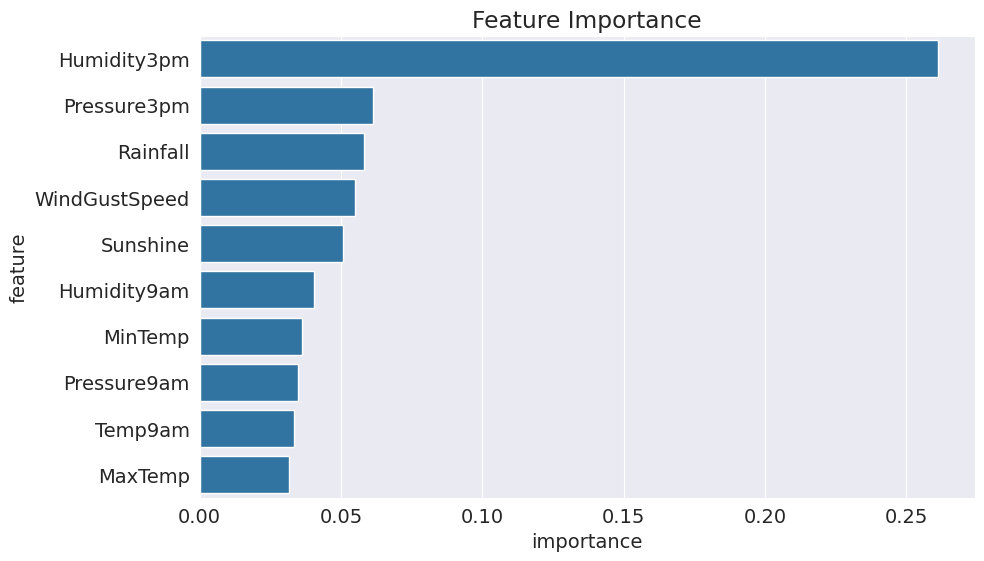

In [ ]:
plt.title("Feature Importance")
sns.barplot(data=importance_df.head(10), x='importance', y='feature')

# **Hyper Parameter Tuning:**

In [ ]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
model.fit(X_train, train_targets)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
model.score(X_train, train_targets)

0.8291308037337859

In [ ]:
model.score(X_val, val_targets)

0.8334397307178921

Great, while the training accuracy of the model has gone down, the validation accuracy of the model has increased significantly.

In [ ]:
model.classes_

array(['No', 'Yes'], dtype=object)

[Text(0.5, 0.875, 'Humidity3pm <= 0.715\ngini = 0.349\nsamples = 98988\nvalue = [76705, 22283]\nclass = No'),
 Text(0.25, 0.625, 'Rainfall <= 0.004\ngini = 0.248\nsamples = 82418\nvalue = [70439.0, 11979.0]\nclass = No'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Sunshine <= 0.532\ngini = 0.198\nsamples = 69252\nvalue = [61538.0, 7714.0]\nclass = No'),
 Text(0.0625, 0.125, 'gini = 0.363\nsamples = 12620\nvalue = [9618, 3002]\nclass = No'),
 Text(0.1875, 0.125, 'gini = 0.153\nsamples = 56632\nvalue = [51920, 4712]\nclass = No'),
 Text(0.375, 0.375, 'Humidity3pm <= 0.513\ngini = 0.438\nsamples = 13166\nvalue = [8901, 4265]\nclass = No'),
 Text(0.3125, 0.125, 'gini = 0.293\nsamples = 4299\nvalue = [3531, 768]\nclass = No'),
 Text(0.4375, 0.125, 'gini = 0.478\nsamples = 8867\nvalue = [5370, 3497]\nclass = No'),
 Text(0.75, 0.625, 'Humidity3pm <= 0.825\ngini = 0.47\nsamples = 16570\nvalue = [6266, 10304]\nclass = Yes'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'WindGustSp

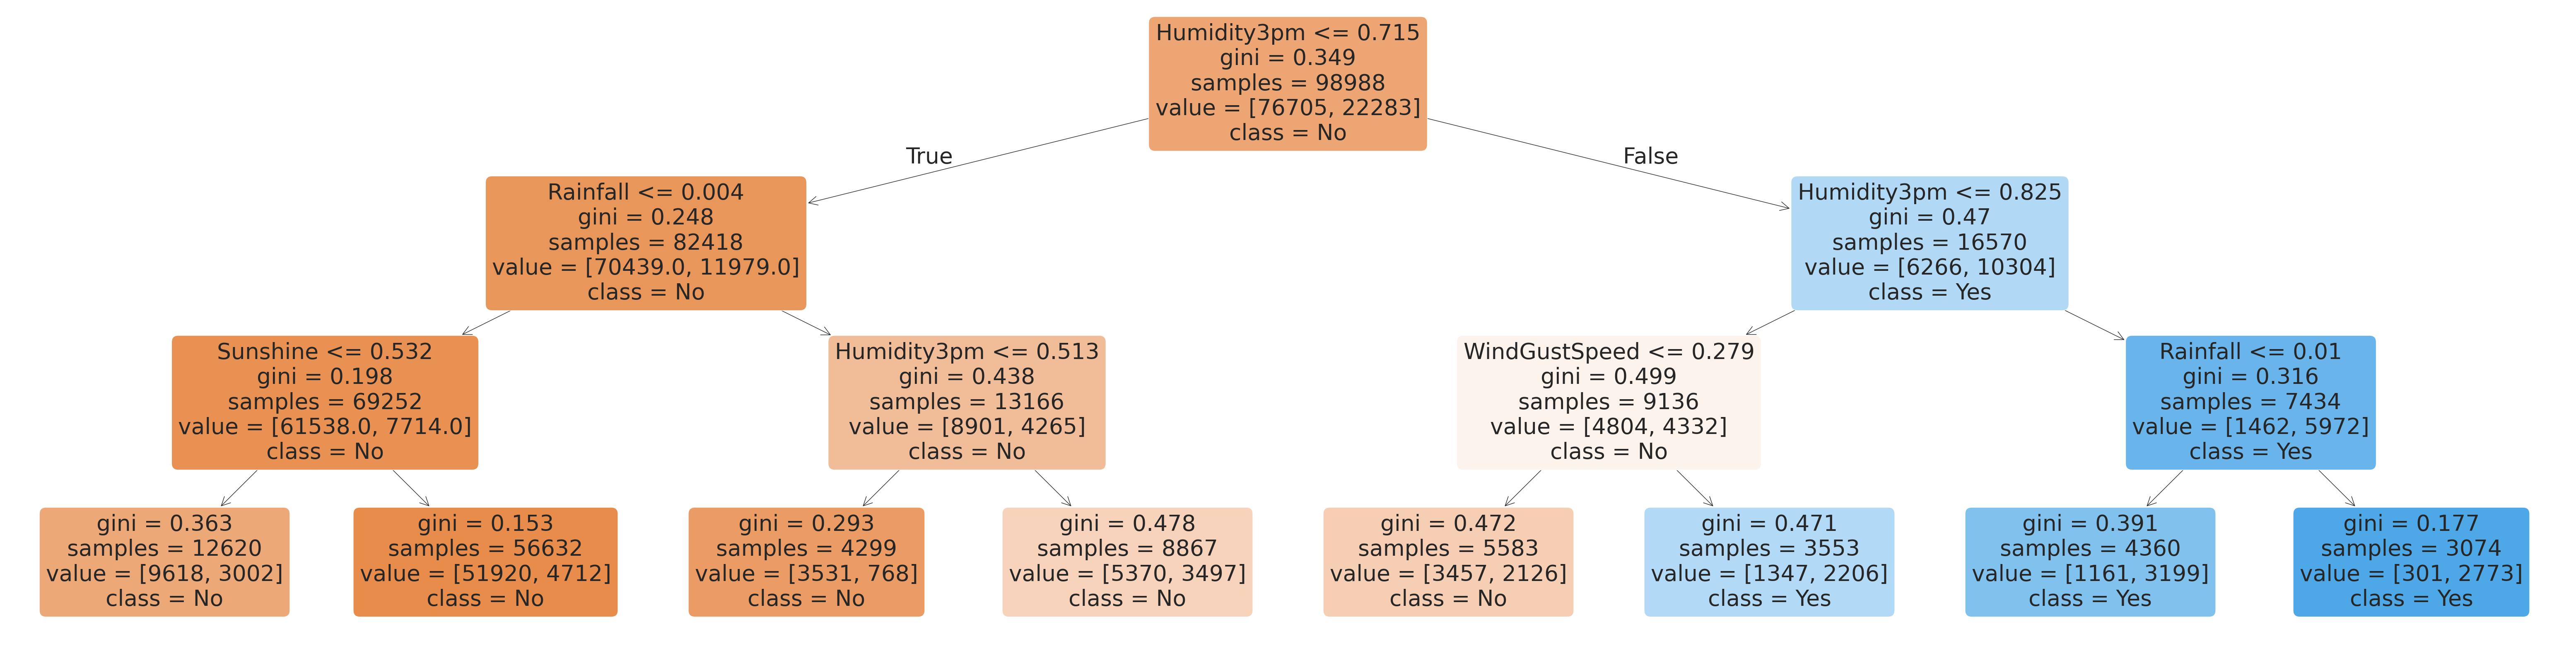

In [ ]:
plt.figure(figsize=(80,20))
plot_tree(model, feature_names=X_train.columns, filled=True, class_names=model.classes_, rounded=True)

In [ ]:
print(export_text(model, feature_names=list(X_train.columns)))

|--- Humidity3pm <= 0.72
|   |--- Rainfall <= 0.00
|   |   |--- Sunshine <= 0.53
|   |   |   |--- class: No
|   |   |--- Sunshine >  0.53
|   |   |   |--- class: No
|   |--- Rainfall >  0.00
|   |   |--- Humidity3pm <= 0.51
|   |   |   |--- class: No
|   |   |--- Humidity3pm >  0.51
|   |   |   |--- class: No
|--- Humidity3pm >  0.72
|   |--- Humidity3pm <= 0.82
|   |   |--- WindGustSpeed <= 0.28
|   |   |   |--- class: No
|   |   |--- WindGustSpeed >  0.28
|   |   |   |--- class: Yes
|   |--- Humidity3pm >  0.82
|   |   |--- Rainfall <= 0.01
|   |   |   |--- class: Yes
|   |   |--- Rainfall >  0.01
|   |   |   |--- class: Yes



### **1. Max Depth**

In [ ]:
def max_depth_err(md):
  model = DecisionTreeClassifier(max_depth=md, random_state=42)
  model.fit(X_train, train_targets)
  train_error = 1 - model.score(X_train, train_targets)
  val_error = 1 - model.score(X_val, val_targets)
  return {'Max Depth': md, 'Training Error': train_error, 'Validation Error': val_error}

In [ ]:
error_df = pd.DataFrame([max_depth_err(i) for i in range(1,21)])

In [ ]:
error_df

,Max Depth,Training Error,Validation Error
0,1,0.184315,0.177935
1,2,0.179547,0.172712
2,3,0.170869,0.166560
3,4,0.165707,0.164355
4,5,0.160676,0.159074
5,6,0.156271,0.157275
6,7,0.153312,0.154605
7,8,0.147806,0.157913
8,9,0.140977,0.156288
9,10,0.132945,0.157681


In [ ]:
best_depth = error_df.loc[error_df['Validation Error'].idxmin()]
best_depth

,6
Max Depth,7.000000
Training Error,0.153312
Validation Error,0.154605


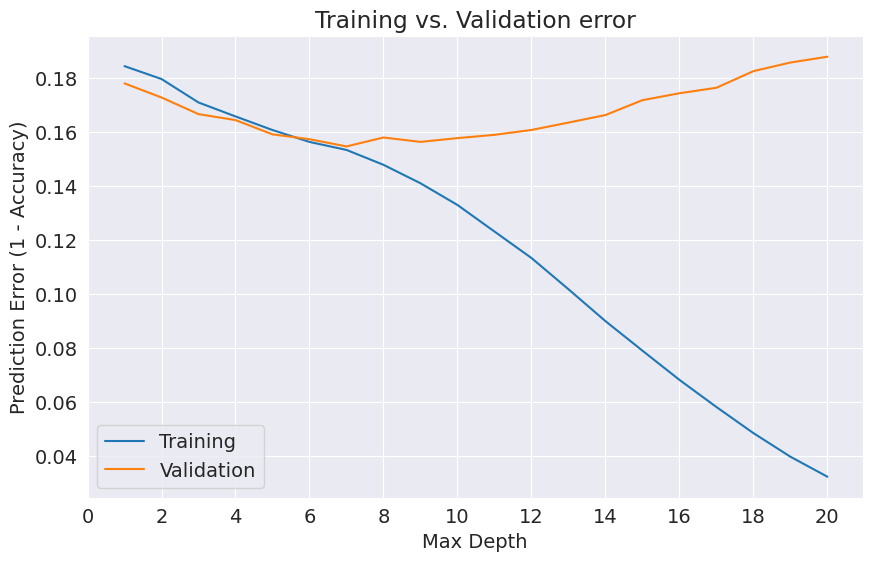

In [ ]:
plt.figure()
plt.plot(error_df["Max Depth"], error_df["Training Error"])
plt.plot(error_df["Max Depth"], error_df["Validation Error"])
plt.title("Training vs. Validation error")
plt.xlabel('Max Depth')
plt.xticks(range(0,21,2))
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation'])

You often need to tune hyperparameters carefully to find the optimal fit. In the above case, it appears that a maximum depth of 10 results in the lowest validation error.

In [ ]:
model = DecisionTreeClassifier(max_depth=10, random_state=42).fit(X_train, train_targets)
model.score(X_train, train_targets), model.score(X_val, val_targets)

(0.8670545924758557, 0.8423190760838024)

### **2. Max Leaf Nodes:**

In [ ]:
model = DecisionTreeClassifier(max_leaf_nodes=128, random_state=42)

In [ ]:
model.fit(X_train, train_targets)

DecisionTreeClassifier(max_leaf_nodes=128, random_state=42)

In [ ]:
model.score(X_train, train_targets)

0.8480421869317493

In [ ]:
model.score(X_val, val_targets)

0.8442342290058615

In [ ]:
model.tree_.max_depth

12

Notice that model was able to achieve a greater depth of 13 for certain paths while keeping other paths shorter.

In [ ]:
model_text = export_text(model, feature_names=list(X_train.columns))
print(model_text[:3000])

|--- Humidity3pm <= 0.72
|   |--- Rainfall <= 0.00
|   |   |--- Sunshine <= 0.53
|   |   |   |--- Pressure3pm <= 0.57
|   |   |   |   |--- WindGustSpeed <= 0.36
|   |   |   |   |   |--- Humidity3pm <= 0.28
|   |   |   |   |   |   |--- class: No
|   |   |   |   |   |--- Humidity3pm >  0.28
|   |   |   |   |   |   |--- Sunshine <= 0.05
|   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |--- Sunshine >  0.05
|   |   |   |   |   |   |   |--- Pressure3pm <= 0.42
|   |   |   |   |   |   |   |   |--- class: Yes
|   |   |   |   |   |   |   |--- Pressure3pm >  0.42
|   |   |   |   |   |   |   |   |--- Humidity3pm <= 0.57
|   |   |   |   |   |   |   |   |   |--- WindDir9am_NE <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- WindDir9am_NNE <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |   |   |--- WindDir9am_NNE >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: No
|   |   |   |   |   |   |   |   |   |--- WindD

In [ ]:
def max_leaf_node(md):
  model = DecisionTreeClassifier(max_leaf_nodes=md, random_state=42).fit(X_train, train_targets)
  train_error = 1 - model.score(X_train, train_targets)
  val_error = 1 - model.score(X_val, val_targets)
  return {'Max Leaf Node': md, 'Training Error': train_error, 'Validation Error': val_error}

### **Coarse search for max_leaf_nodes**

In [ ]:
leaf_node_range = [2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 11114]
leaf_node_error_df = pd.DataFrame([max_leaf_node(i) for i in leaf_node_range])

In [ ]:
leaf_node_error_df

,Max Leaf Node,Training Error,Validation Error
0,2,0.184315,0.177935
1,5,0.179547,0.172712
2,10,0.167061,0.164761
3,20,0.162757,0.162382
4,50,0.156847,0.157043
5,100,0.153998,0.155708
6,200,0.146149,0.155592
7,500,0.130965,0.155940
8,1000,0.115378,0.158377
9,2000,0.090920,0.161569


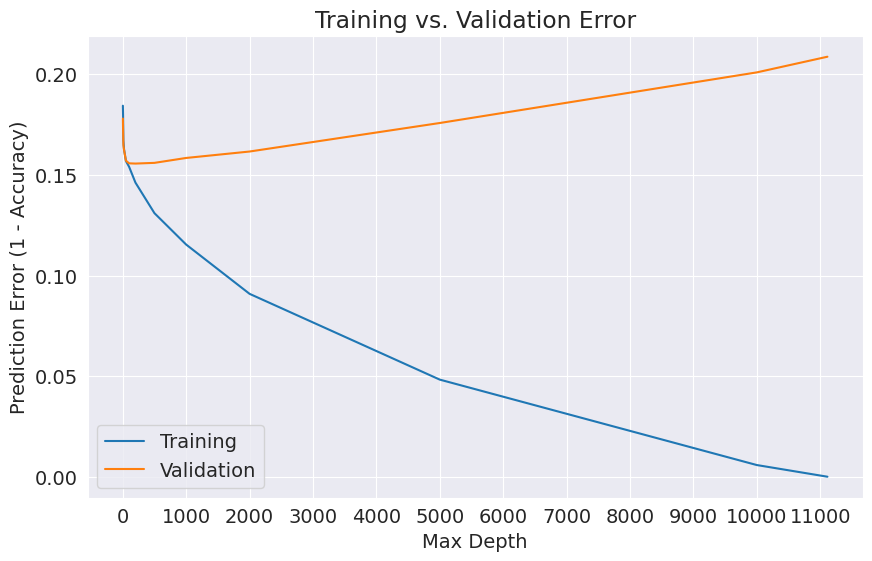

In [ ]:
plt.figure()
plt.plot(leaf_node_error_df['Max Leaf Node'], leaf_node_error_df['Training Error'])
plt.plot(leaf_node_error_df['Max Leaf Node'], leaf_node_error_df['Validation Error'])
plt.title("Training vs. Validation Error")
plt.xlabel('Max Depth')
plt.xticks(range(0,11114,1000))
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation'])

In [ ]:
best_result = leaf_node_error_df.loc[leaf_node_error_df['Validation Error'].idxmin()]
best_result

,6
Max Leaf Node,200.000000
Training Error,0.146149
Validation Error,0.155592


### **Fine search around 200**

In [ ]:
leaf_node_error_df = pd.DataFrame([max_leaf_node(i) for i in range(2,220,2)])

In [ ]:
leaf_node_error_df

,Max Leaf Node,Training Error,Validation Error
0,2,0.184315,0.177935
1,4,0.179547,0.172712
2,6,0.179547,0.172712
3,8,0.170869,0.166560
4,10,0.167061,0.164761
5,12,0.166303,0.165225
6,14,0.165707,0.164355
7,16,0.165707,0.164355
8,18,0.164596,0.162904
9,20,0.162757,0.162382


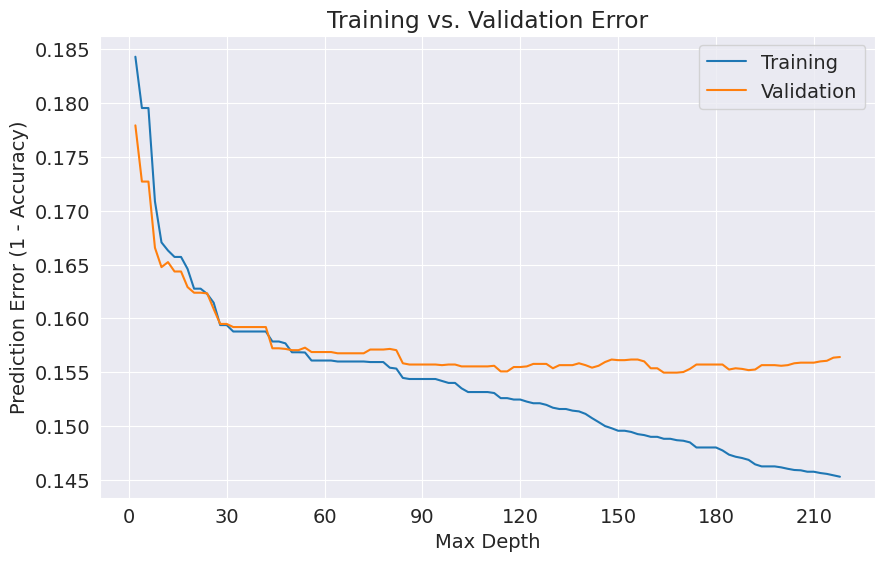

In [ ]:
plt.figure()
plt.plot(leaf_node_error_df['Max Leaf Node'], leaf_node_error_df['Training Error'])
plt.plot(leaf_node_error_df['Max Leaf Node'], leaf_node_error_df['Validation Error'])
plt.title("Training vs. Validation Error")
plt.xlabel('Max Depth')
plt.xticks(range(0,220,30))
plt.ylabel('Prediction Error (1 - Accuracy)')
plt.legend(['Training', 'Validation'])

In [ ]:
best_result = leaf_node_error_df.loc[leaf_node_error_df["Validation Error"].idxmin()]

In [ ]:
best_result

,81
Max Leaf Node,164.000000
Training Error,0.148806
Validation Error,0.154953


### **Finding best combination of max_depth and max_leaf_nodes**

In [ ]:
def max_depth_and_leaf(md, ml):
  model = DecisionTreeClassifier(max_depth=md, max_leaf_nodes=ml, random_state=42).fit(X_train,train_targets)
  train_error = 1 - model.score(X_train,train_targets)
  val_error = 1 - model.score(X_val,val_targets)
  return {"Max Depth": md, "Max Leaf Node": ml, "Training Error": train_error, "Validation Error": val_error}

In [ ]:
max_depth_and_leaf_df = pd.DataFrame([max_depth_and_leaf(i,j) for i in range(1,49) for j in range(30,60,2)])

In [ ]:
max_depth_and_leaf_df

,Max Depth,Max Leaf Node,Training Error,Validation Error
0,1,30,0.184315,0.177935
1,1,32,0.184315,0.177935
2,1,34,0.184315,0.177935
3,1,36,0.184315,0.177935
4,1,38,0.184315,0.177935
...,...,...,...,...
715,48,50,0.156847,0.157043
716,48,52,0.156847,0.157043
717,48,54,0.156827,0.157275
718,48,56,0.156080,0.156868


In [ ]:
best_result = max_depth_and_leaf_df.loc[max_depth_and_leaf_df["Validation Error"].idxmin()]

In [ ]:
best_result

,104
Max Depth,7.000000
Max Leaf Node,58.000000
Training Error,0.156009
Validation Error,0.156520


In [ ]:
model = DecisionTreeClassifier(max_depth=7, max_leaf_nodes=58, random_state=42)

In [ ]:
model.fit(X_train, train_targets)

DecisionTreeClassifier(max_depth=7, max_leaf_nodes=58, random_state=42)

In [ ]:
model.score(X_train, train_targets)

0.8439911908514164

In [ ]:
model.score(X_val, val_targets)

0.8434797748244444

The optimized Decision Tree model uses **`max_depth=7`** and **`max_leaf_nodes=58`**, achieving a score of **0.8440 on the training set** and **0.8435 on the test set**. The very small difference between the training and test scores indicates that the model generalizes well with **minimal overfitting**. This provides a strong baseline for comparing the performance of the upcoming **Random Forest** model.

# **Random Forest Model:**

In [2]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
model = RandomForestClassifier(n_jobs=-1, random_state=42)

n_jobs allow the random forest to use multiple parallel workers to train decision trees, and random_state ensures that we get the same result for each execution.

In [ ]:
model.fit(X_train, train_targets)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
model.score(X_train, train_targets)

0.9999595910615429

In [ ]:
model.score(X_val, val_targets)

0.8560733561604086

In [ ]:
train_probs = model.predict_proba(X_train)
train_probs

array([[0.95, 0.05],
       [0.97, 0.03],
       [1.  , 0.  ],
       ...,
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.95, 0.05]])

We can access individual decision trees using model.estimators_

In [ ]:
len(model.estimators_)

100

In [ ]:
model.estimators_[0]

DecisionTreeClassifier(max_features='sqrt', random_state=1608637542)

[Text(0.5, 0.875, 'Sunshine <= 0.409\ngini = 0.347\nsamples = 62607\nvalue = [76887, 22101]\nclass = No'),
 Text(0.25, 0.625, 'Pressure9am <= 0.609\ngini = 0.499\nsamples = 11288\nvalue = [9272, 8542]\nclass = No'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Cloud9am <= 0.833\ngini = 0.475\nsamples = 6067\nvalue = [3702, 5808]\nclass = Yes'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'WindGustDir_NNE <= 0.5\ngini = 0.442\nsamples = 5221\nvalue = [5570.0, 2734.0]\nclass = No'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'WindGustDir_ENE <= 0.5\ngini = 0.278\nsamples = 51319\nvalue = [67615, 13559]\nclass = No'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'MaxTemp <= 0.438\ngini = 0.282\nsamples = 48340\nvalue = [63506, 13002]\nclass = No'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Pressure9am <= 0.553\ngin

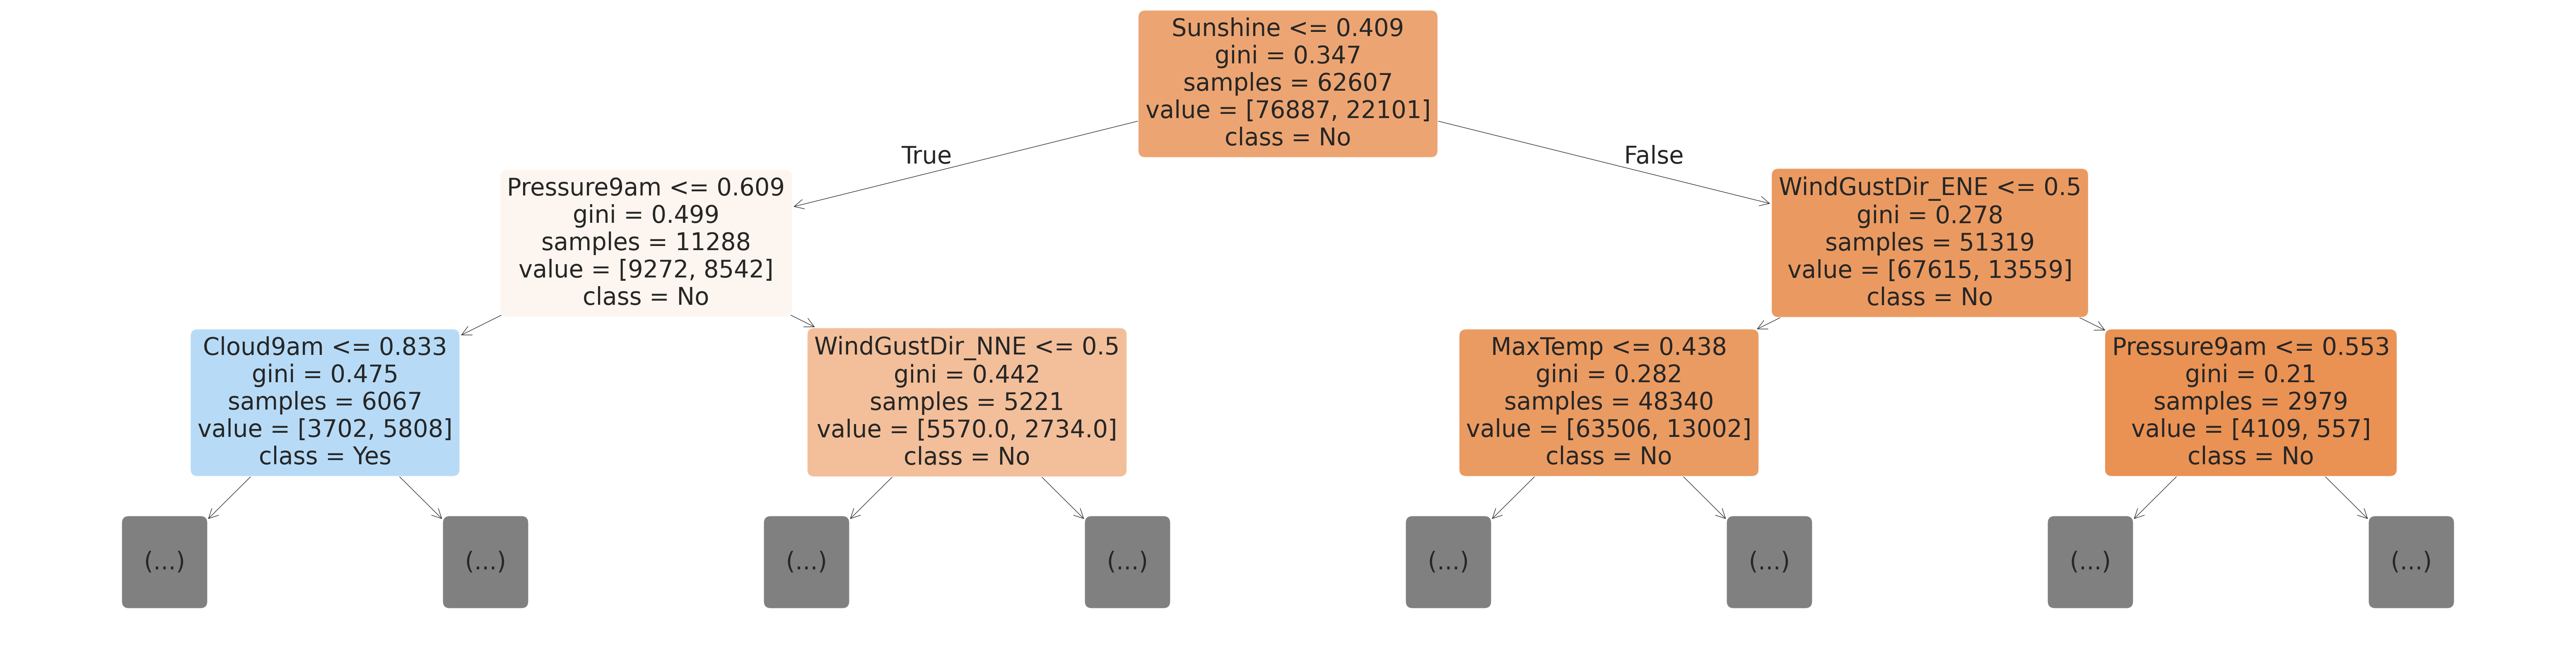

In [ ]:
plt.figure(figsize=(80,20))
plot_tree(model.estimators_[0], max_depth=2, feature_names=X_train.columns, filled=True, rounded=True, class_names=model.classes_)

[Text(0.5, 0.875, 'RainToday_Yes <= 0.5\ngini = 0.349\nsamples = 62610\nvalue = [76714, 22274]\nclass = No'),
 Text(0.25, 0.625, 'WindGustDir_ESE <= 0.5\ngini = 0.262\nsamples = 48715\nvalue = [65024, 11930]\nclass = No'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Pressure3pm <= 0.489\ngini = 0.267\nsamples = 46043\nvalue = [61211.0, 11515.0]\nclass = No'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'WindDir9am_W <= 0.5\ngini = 0.177\nsamples = 2672\nvalue = [3813, 415]\nclass = No'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'Cloud3pm <= 0.722\ngini = 0.498\nsamples = 13895\nvalue = [11690, 10344]\nclass = No'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'Location_Witchcliffe <= 0.5\ngini = 0.474\nsamples = 9190\nvalue = [8862, 5590]\nclass = No'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Evaporation <=

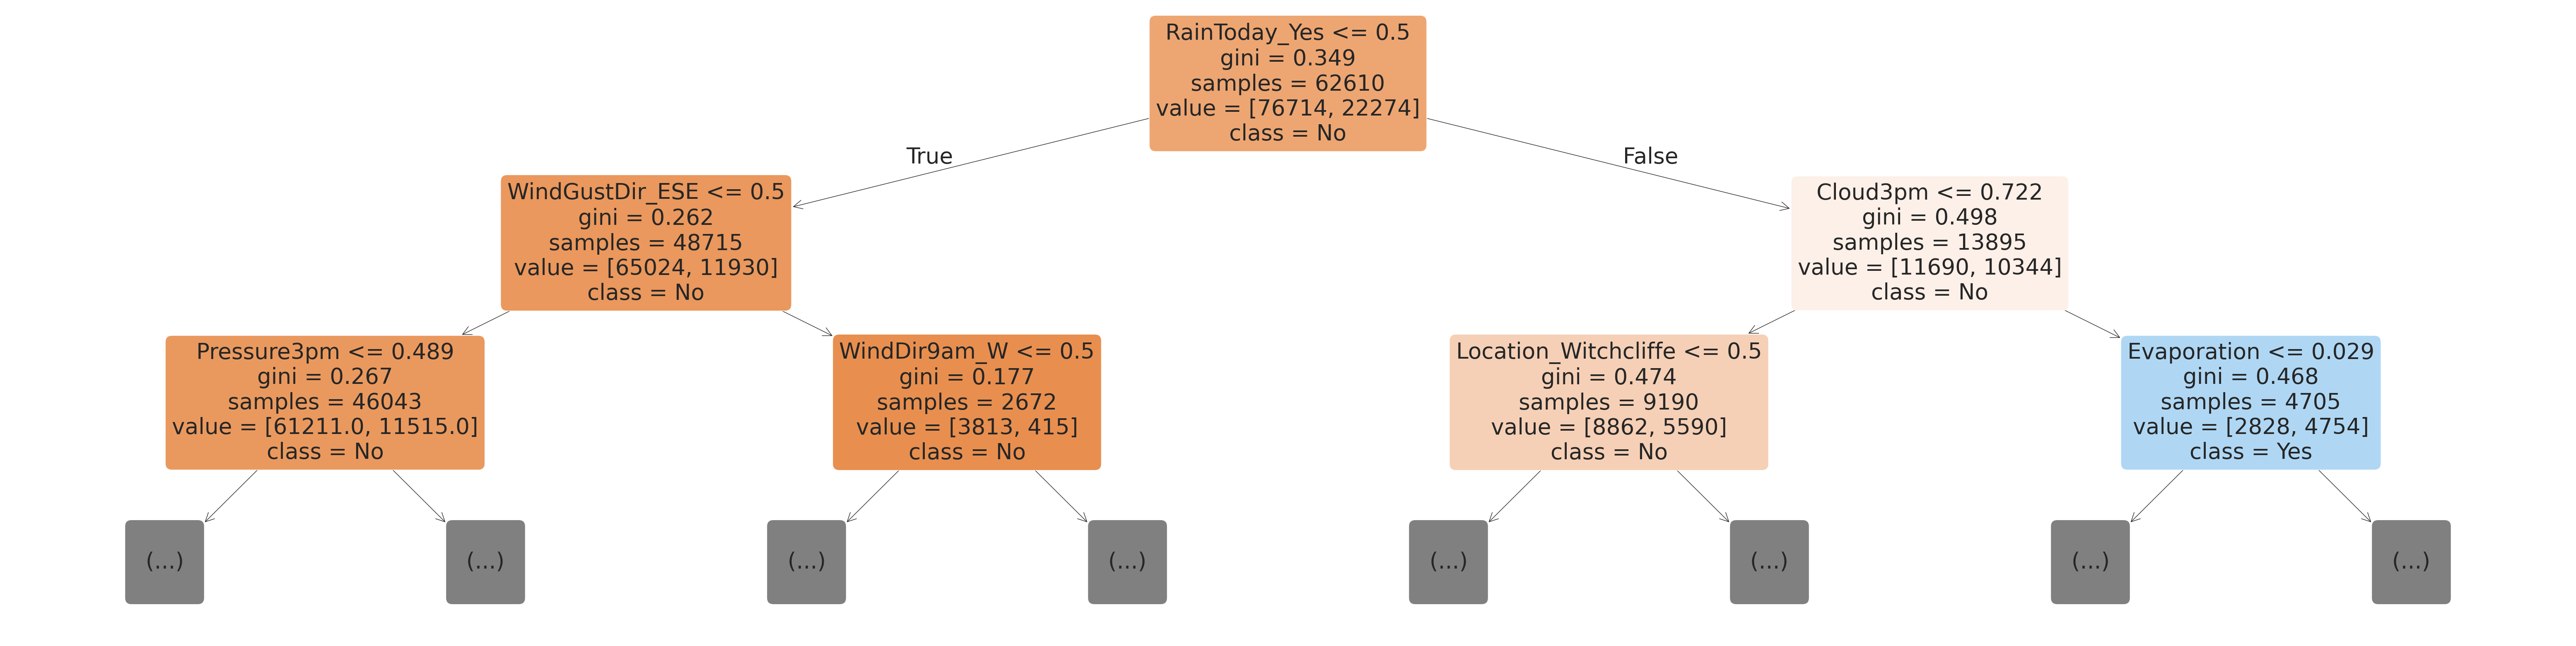

In [ ]:
plt.figure(figsize=(80,20))
plot_tree(model.estimators_[20], max_depth=2, feature_names=X_train.columns, filled=True, rounded=True, class_names=model.classes_)

Just like decision tree, random forests also assign an "importance" to each feature, by combining the importance values from individual trees.

In [ ]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

In [ ]:
importance_df

,feature,importance
9,Humidity3pm,0.137909
4,Sunshine,0.054994
11,Pressure3pm,0.053791
8,Humidity9am,0.049366
10,Pressure9am,0.048191
5,WindGustSpeed,0.047093
2,Rainfall,0.045536
15,Temp3pm,0.044610
1,MaxTemp,0.042301
0,MinTemp,0.041096


<Axes: title={'center': 'Feature importance'}, xlabel='importance', ylabel='feature'>

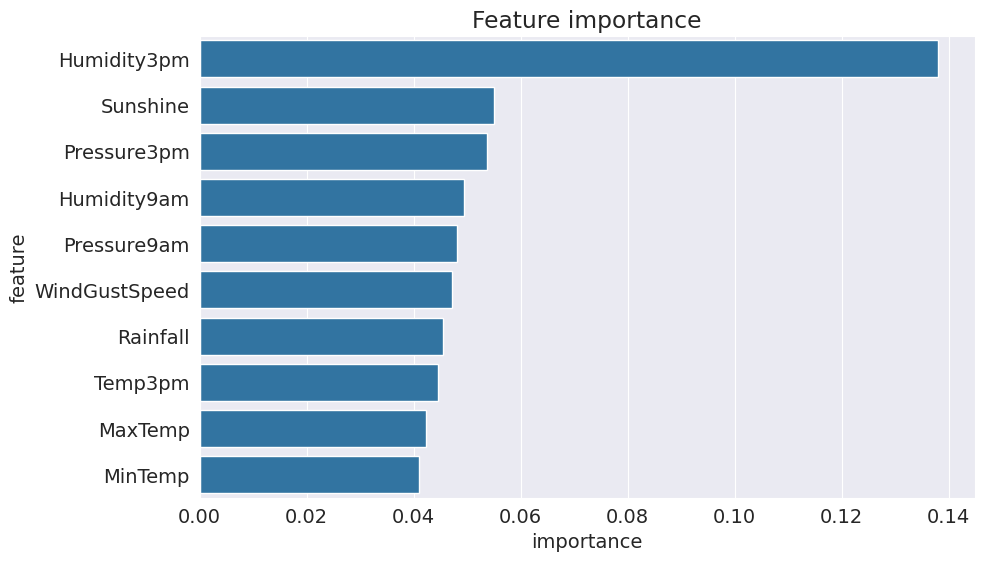

In [ ]:
plt.title("Feature importance")
sns.barplot(data=importance_df.head(10), x='importance', y='feature')

Notice that the distribution is a lot less skewed than that for a single decision tree. This is because now we are depending on combination of all the different decision trees and every feature gets some importance because it is important in some decision tree.

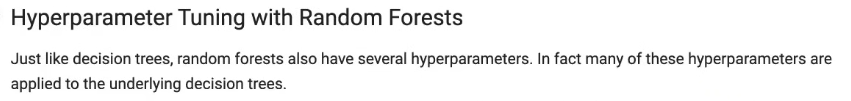

Lets create a base model with which we can compare models with tuned parameters.

In [ ]:
base_model = RandomForestClassifier(n_jobs=-1, random_state=42).fit(X_train, train_targets)

In [ ]:
base_train_acc = base_model.score(X_train, train_targets)
base_val_acc = base_model.score(X_val, val_targets)

In [ ]:
base_accs = base_train_acc, base_val_acc
base_accs

(0.9999595910615429, 0.8560733561604086)

We can use this as a benchmark for hyperparameter tuning.

# **1. n_estimators:**

### **10 Estimators**

In [ ]:
model = RandomForestClassifier(n_jobs=-1, random_state=42, n_estimators=10)

In [1]:
model.fit(X_train, train_targets)

NameError: name 'model' is not defined

In [ ]:
train_acc = model.score(X_train, train_targets)
val_acc = model.score(X_val, val_targets)

In [ ]:
base_accs = train_acc, val_acc
base_accs

(0.987331797793672, 0.8431896001392839)

### **500 Estimators**

In [34]:
model = RandomForestClassifier(n_jobs=-1, random_state=42, n_estimators=500)

In [35]:
model.fit(X_train, train_targets)

RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=42)

In [36]:
train_acc = model.score(X_train, train_targets)
val_acc = model.score(X_val, val_targets)

In [37]:
base_accs = train_acc, val_acc
base_accs

(0.999913532209252, 0.8299104791995787)

# **2. max_depth & max_leaf_nodes:**

Let's define a helper function test_params to make it easy to test hyperparameters.

In [24]:
def test_params(**params):
  model = RandomForestClassifier(n_jobs=-1, random_state=42, **params).fit(X_train, train_targets)
  train_freq = model.score(X_train, train_targets)
  train_error = 1 - model.score(X_train, train_targets)
  val_freq = model.score(X_val, val_targets)
  val_error = 1 - model.score(X_val, val_targets)
  return {**params, "Training Frequency": train_freq, "Training Error": train_error, "Validation Frequency": val_freq, "Validation Error": val_error}

In [ ]:
test_params(max_depth=5)

{'max_depth': 5,
 'Training Frequency': 0.8197559300117186,
 'Training Error': 0.18024406998828135,
 'Validation Frequency': 0.8239800359816609,
 'Validation Error': 0.17601996401833908}

In [ ]:
test_params(max_depth=26)

{'max_depth': 26,
 'Training Frequency': 0.9814927061866084,
 'Training Error': 0.018507293813391557,
 'Validation Frequency': 0.8563054959085369,
 'Validation Error': 0.14369450409146312}

In [ ]:
test_params(max_leaf_nodes=2**5)

{'max_leaf_nodes': 32,
 'Training Frequency': 0.8313937042873883,
 'Training Error': 0.16860629571261165,
 'Validation Frequency': 0.8335558005919563,
 'Validation Error': 0.16644419940804367}

In [ ]:
test_params(max_leaf_nodes=2**20)

{'max_leaf_nodes': 1048576,
 'Training Frequency': 0.9999595910615429,
 'Training Error': 4.040893845713711e-05,
 'Validation Frequency': 0.8558992513493123,
 'Validation Error': 0.14410074865068767}

In [ ]:
base_accs

(0.9999797955307714, 0.8571179850269862)

In [ ]:
leaf_node_range = [2, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 11114]
combine_error_df = pd.DataFrame([test_params(max_depth=i,max_leaf_nodes=j) for i in range(1,40) for j in leaf_node_range])

In [ ]:
combine_error_df

,max_depth,max_leaf_nodes,Training Frequency,Training Error,Validation Frequency,Validation Error
0,1,2,0.777737,0.222263,0.756486,0.243514
1,1,5,0.777737,0.222263,0.756486,0.243514
2,1,10,0.777737,0.222263,0.756486,0.243514
3,1,20,0.777737,0.222263,0.756486,0.243514
4,1,50,0.777737,0.222263,0.756486,0.243514
...,...,...,...,...,...,...
502,39,1000,0.915158,0.084842,0.834525,0.165475
503,39,2000,0.954483,0.045517,0.837794,0.162206
504,39,5000,0.999866,0.000134,0.837385,0.162615
505,39,10000,0.999866,0.000134,0.837385,0.162615


In [ ]:
best_result = combine_error_df.loc[combine_error_df["Validation Error"].idxmin()]
best_result

,465
max_depth,36.000000
max_leaf_nodes,5000.000000
Training Frequency,0.999833
Training Error,0.000167
Validation Frequency,0.839224
Validation Error,0.160776


### **3. max_features:**

In [25]:
test_params(max_features='log2')

{'max_features': 'log2',
 'Training Frequency': 0.999913532209252,
 'Training Error': 8.646779074794608e-05,
 'Validation Frequency': 0.8275408109531333,
 'Validation Error': 0.17245918904686675}

In [26]:
test_params(max_features=5)

{'max_features': 5,
 'Training Frequency': 0.9998702983138781,
 'Training Error': 0.00012970168612191912,
 'Validation Frequency': 0.8249078462348605,
 'Validation Error': 0.17509215376513954}

In [27]:
test_params(max_features=20)

{'max_features': 20,
 'Training Frequency': 0.999913532209252,
 'Training Error': 8.646779074794608e-05,
 'Validation Frequency': 0.8280674038967878,
 'Validation Error': 0.1719325961032122}

### **4. min_samples_split & min_samples_leaf:**

In [28]:
test_params(min_samples_split=5, min_samples_leaf=2)

{'min_samples_split': 5,
 'min_samples_leaf': 2,
 'Training Frequency': 0.9598357111975789,
 'Training Error': 0.040164288802421066,
 'Validation Frequency': 0.8267509215376514,
 'Validation Error': 0.1732490784623486}

In [29]:
test_params(min_samples_split=100, min_samples_leaf=60)

{'min_samples_split': 100,
 'min_samples_leaf': 60,
 'Training Frequency': 0.8536964980544747,
 'Training Error': 0.14630350194552533,
 'Validation Frequency': 0.8154291732490785,
 'Validation Error': 0.1845708267509215}

### **5. min_impurity_decrease:**

In [30]:
test_params(min_impurity_decrease=1e-7)

{'min_impurity_decrease': 1e-07,
 'Training Frequency': 0.9998702983138781,
 'Training Error': 0.00012970168612191912,
 'Validation Frequency': 0.8304370721432333,
 'Validation Error': 0.16956292785676674}

In [31]:
test_params(min_impurity_decrease=1e-6)

{'min_impurity_decrease': 1e-06,
 'Training Frequency': 0.9993082576740164,
 'Training Error': 0.0006917423259835687,
 'Validation Frequency': 0.825434439178515,
 'Validation Error': 0.174565560821485}

In [32]:
test_params(min_impurity_decrease=1e-2)

{'min_impurity_decrease': 0.01,
 'Training Frequency': 0.7811067877215737,
 'Training Error': 0.21889321227842629,
 'Validation Frequency': 0.7543443917851501,
 'Validation Error': 0.24565560821484989}

In [38]:
base_accs

(0.999913532209252, 0.8299104791995787)

### **6. Bootstrap (max_samples):**

In [39]:
test_params(bootstrap=False)

{'bootstrap': False,
 'Training Frequency': 0.999913532209252,
 'Training Error': 8.646779074794608e-05,
 'Validation Frequency': 0.8293838862559242,
 'Validation Error': 0.17061611374407581}

In [40]:
base_accs

(0.999913532209252, 0.8299104791995787)

In [41]:
test_params(max_samples=0.9)

{'max_samples': 0.9,
 'Training Frequency': 0.9996541288370082,
 'Training Error': 0.00034587116299178433,
 'Validation Frequency': 0.8288572933122696,
 'Validation Error': 0.17114270668773035}

In [42]:
base_accs

(0.999913532209252, 0.8299104791995787)

### **class_weight**

In [43]:
train_targets.value_counts()

,count
RainTomorrow,
No,18067
Yes,5063


In [44]:
train_targets.value_counts() / len(train_targets)

,count
RainTomorrow,
No,0.781107
Yes,0.218893


In [45]:
test_params(class_weight='balanced')

{'class_weight': 'balanced',
 'Training Frequency': 0.999913532209252,
 'Training Error': 8.646779074794608e-05,
 'Validation Frequency': 0.8230647709320695,
 'Validation Error': 0.17693522906793047}

In [46]:
test_params(class_weight={'No':1, 'Yes':2})

{'class_weight': {'No': 1, 'Yes': 2},
 'Training Frequency': 0.999913532209252,
 'Training Error': 8.646779074794608e-05,
 'Validation Frequency': 0.8262243285939969,
 'Validation Error': 0.17377567140600314}

In [47]:
base_accs

(0.999913532209252, 0.8299104791995787)

### **Putting it all together:**

In [48]:
model = RandomForestClassifier(
    n_jobs=-1,
    random_state=42,
    n_estimators=500,
    max_features=7,
    max_depth=30,
    class_weight={'No':1, 'Yes':1.5}
)

In [49]:
model.fit(X_train,train_targets)

RandomForestClassifier(class_weight={'No': 1, 'Yes': 1.5}, max_depth=30,
                       max_features=7, n_estimators=500, n_jobs=-1,
                       random_state=42)

In [50]:
model.score(X_train,train_targets), model.score(X_val,val_targets)

(0.9997838305231301, 0.830173775671406)

Let's compute accuracy on test set also.

In [51]:
model.score(X_test,test_targets)

0.843241196516471

### **Making Predictions on New Inputs:**

In [52]:
def predict_input(model, single_input):
  input_df = pd.DataFrame([single_input])
  input_df[numeric_cols] = imputer.transform(input_df[numeric_cols])
  input_df[numeric_cols] = scalar.transform(input_df[numeric_cols])
  input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
  X_input = input_df[numeric_cols + encoded_cols]
  pred = model.predict(X_input)[0]
  prob = model.predict_proba(X_input)[0][list(model.classes_).index(pred)]
  return pred, prob

In [53]:
new_input = {
    'Date': '2021-06-19',
    'Location': 'Katherine',
    'MinTemp': 23.2,
    'MaxTemp': 33.2,
    'Rainfall': 10.2,
    'Evaporation': 4.2,
    'Sunshine': np.nan,
    'WindGustDir': 'NNW',
    'WindGustSpeed': 52.0,
    'WindDir9am': 'NW',
    'WindDir3pm': 'NNE',
    'WindSpeed9am': 13.0,
    'WindSpeed3pm': 20.0,
    'Humidity9am': 89.0,
    'Humidity3pm': 58.0,
    'Pressure9am': 1004.8,
    'Pressure3pm': 1001.5,
    'Cloud9am': 8.0,
    'Cloud3pm': 5.0,
    'Temp9am': 25.7,
    'Temp3pm': 33.0,
    'RainToday': "Yes"
}

In [54]:
predict_input(model,new_input)

('No', np.float64(0.5156124999999999))

# **Conclusion**

This project compares Logistic Regression, Decision Tree, and Random Forest models for binary classification. Logistic Regression provides a strong baseline with **87.41% validation accuracy** and a very small difference between training and validation performance, indicating stable generalization. The initial Decision Tree severely overfits, achieving nearly **100% training accuracy** but only **79.15% validation accuracy**. Hyperparameter tuning improves the Decision Tree's generalization, resulting in **84.40% training accuracy** and **84.35% validation accuracy**.

Random Forest performs better than the untuned Decision Tree, achieving **85.61% validation accuracy**, while hyperparameter tuning further improves its validation accuracy to **87.13%**. The tuned Random Forest achieves **100% training accuracy**, **87.13% validation accuracy**, and **86.40% test accuracy**. The small difference between validation and test accuracy indicates that the model maintains reasonably consistent performance on unseen data, although the large training-validation gap indicates some overfitting.

Overall, **Logistic Regression has the highest validation accuracy (87.41%)**, while the **tuned Random Forest achieves strong and competitive performance with 86.40% test accuracy**. The final model choice should therefore consider not only accuracy but also metrics such as **precision, recall, F1-score, and ROC-AUC**, particularly when the cost of incorrect predictions differs between the two classes.
